# Notebook 06 — Simulación Monte Carlo del clima por escenario ENSO

Generación de $N$ trayectorias sintéticas de temperatura y precipitación diarias para Casanare y Tolima, usando los modelos calibrados en los notebooks anteriores:

- **Temperatura** → Alaton (notebook 02) con innovaciones Normal o $t$-Student según AIC (notebook 03).
- **Precipitación** → Bernoulli-Gamma (notebook 05) con Logit para ocurrencia y Gamma para intensidad. Los regresores son estacionalidad cíclica + lags de precipitación; **no se incluye temperatura como feature** para evitar dependencia entre los dos modelos.

**Condicionamiento por ENSO** — para capturar el efecto diferencial de Niño/Neutro/Niña, los modelos se re-calibran sobre los subconjuntos históricos correspondientes a cada fase (clasificadas en CapaB_ENSO según RONI: Niño si RONI ≥ +0.5, Niña si ≤ −0.5, Neutro en otro caso). Esto produce tres conjuntos de parámetros por departamento y tres bancos de trayectorias.

**Output** — trayectorias diarias en `data/processed/mc_paths.parquet` (formato largo `[scenario, dpto, path_id, date, t_max, precip]`) para uso en los notebooks 07 (índices HDD/CRI) y 08 (valoración).

In [15]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning
from IPython.display import display

# Suprimir warnings ruidosos que no implican problemas reales
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED       = 42
N_PATHS    = 10000    # subir a 10_000 para reportes finales; 1_000 corre rápido en dev
N_DIAS_SIM = 365     # un año calendario

OUT_DIR = Path("../data/processed")
rng = np.random.default_rng(SEED)

## 1. Carga de datos y parámetros calibrados

In [16]:
df = pd.read_excel("../data/processed/Modelo_Completo.xlsx", parse_dates=["date"]).set_index("date")

VAR_TEMP = "t_max"
df_Casanare = df[df["department"] == "Casanare"][[VAR_TEMP, "precip"]].copy()
df_Tolima   = df[df["department"] == "Tolima"  ][[VAR_TEMP, "precip"]].copy()

# Fases ENSO mensuales -> broadcast a frecuencia diaria
enso = pd.read_excel("../data/processed/Modelo_Completo.xlsx", sheet_name="CapaB_ENSO")
enso["date"] = pd.to_datetime(enso["date"])
enso_daily = enso.set_index("date")[["roni", "fase"]].resample("D").ffill()

df_Casanare = df_Casanare.join(enso_daily, how="left").dropna()
df_Tolima   = df_Tolima.join(enso_daily,   how="left").dropna()

with open(OUT_DIR / "params_alaton.json")       as f: P_ALATON = json.load(f)
with open(OUT_DIR / "params_innovaciones.json") as f: P_INNOV  = json.load(f)
with open(OUT_DIR / "params_bg.json")           as f: P_BG     = json.load(f)

print("Parámetros cargados:")
print(f"  - params_alaton.json       ({list(P_ALATON.keys())})")
print(f"  - params_innovaciones.json ({list(P_INNOV.keys())})")
print(f"  - params_bg.json           ({list(P_BG.keys())})")
print("\nThresholds de lluvia exportados por el notebook 05:")
for d in P_BG:
    print(f"  {d:9s}  threshold = {P_BG[d]['threshold_lluvia']} mm")
print(f"\nFases ENSO en muestra Casanare: {df_Casanare['fase'].value_counts().to_dict()}")
df_Casanare

Parámetros cargados:
  - params_alaton.json       (['Tolima', 'Casanare'])
  - params_innovaciones.json (['Tolima', 'Casanare'])
  - params_bg.json           (['Tolima', 'Casanare'])

Thresholds de lluvia exportados por el notebook 05:
  Tolima     threshold = 5 mm
  Casanare   threshold = 3 mm

Fases ENSO en muestra Casanare: {'Neutro': 2466, 'Niña': 1797, 'Niño': 1551}


,t_max,precip,roni,fase
date,,,,
2010-01-01,32.519880,0.000000,1.5,Niño
2010-01-02,33.657143,0.000000,1.5,Niño
2010-01-03,33.657143,0.000000,1.5,Niño
2010-01-04,34.742857,0.000000,1.5,Niño
2010-01-05,35.385714,0.000000,1.5,Niño
...,...,...,...,...
2025-11-27,31.571429,0.000000,-0.6,Niña
2025-11-28,31.871429,0.857143,-0.6,Niña
2025-11-29,32.200000,0.000000,-0.6,Niña



=== Tolima ===

Niño
  Observaciones: 1,551
  Rango fecha:   2010-01-01 -> 2024-05-31
  Años cubiertos: 2010 -> 2024
  Media t_max:   30.99
  Media precip:   4.79


,n_dias
date,
2010,90
2014,92
2015,365
2016,152
2018,122
2019,242
2020,91
2023,245
2024,152



Neutro
  Observaciones: 2,466
  Rango fecha:   2010-04-01 -> 2025-09-30
  Años cubiertos: 2010 -> 2025
  Media t_max:   30.49
  Media precip:   5.21


,n_dias
date,
2010,61
2011,61
2012,275
2013,365
2014,273
2016,61
2017,273
2018,153
2019,123



Niña
  Observaciones: 1,797
  Rango fecha:   2010-06-01 -> 2025-12-01
  Años cubiertos: 2010 -> 2025
  Media t_max:   29.47
  Media precip:   6.73


,n_dias
date,
2010,214
2011,304
2012,91
2016,153
2017,92
2018,90
2020,153
2021,242
2022,365


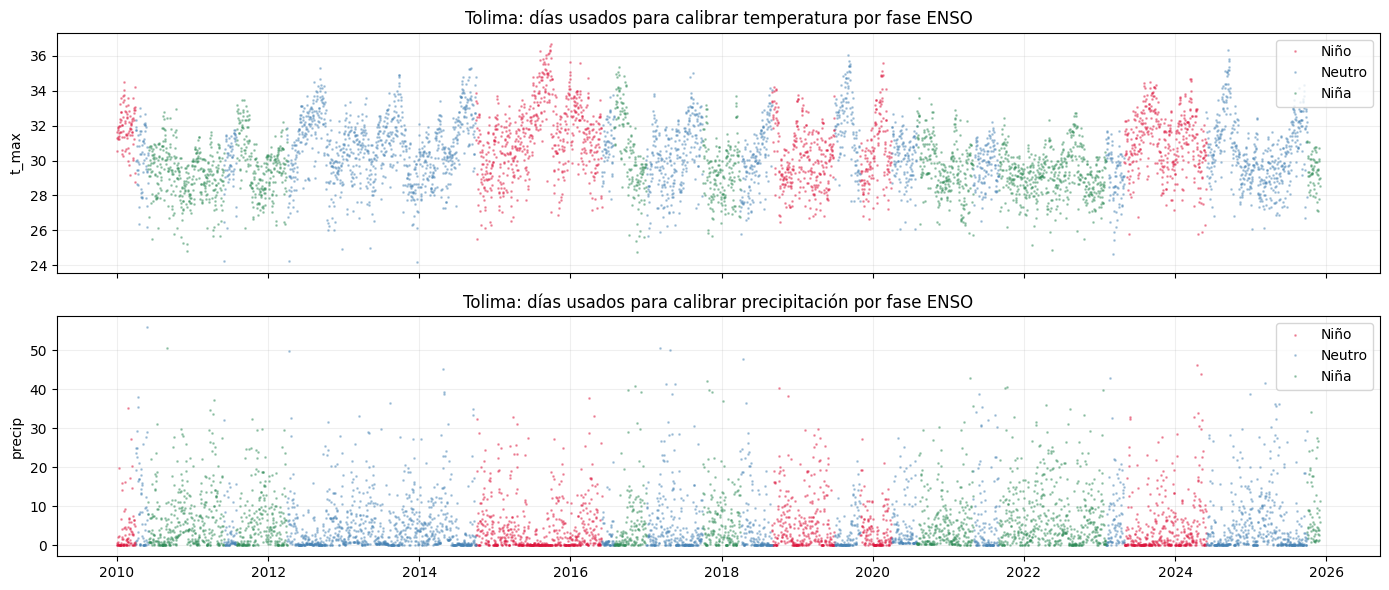


=== Casanare ===

Niño
  Observaciones: 1,551
  Rango fecha:   2010-01-01 -> 2024-05-31
  Años cubiertos: 2010 -> 2024
  Media t_max:   32.09
  Media precip:   5.94


,n_dias
date,
2010,90
2014,92
2015,365
2016,152
2018,122
2019,242
2020,91
2023,245
2024,152



Neutro
  Observaciones: 2,466
  Rango fecha:   2010-04-01 -> 2025-09-30
  Años cubiertos: 2010 -> 2025
  Media t_max:   30.81
  Media precip:   8.61


,n_dias
date,
2010,61
2011,61
2012,275
2013,365
2014,273
2016,61
2017,273
2018,153
2019,123



Niña
  Observaciones: 1,797
  Rango fecha:   2010-06-01 -> 2025-12-01
  Años cubiertos: 2010 -> 2025
  Media t_max:   31.11
  Media precip:   7.56


,n_dias
date,
2010,214
2011,304
2012,91
2016,153
2017,92
2018,90
2020,153
2021,242
2022,365


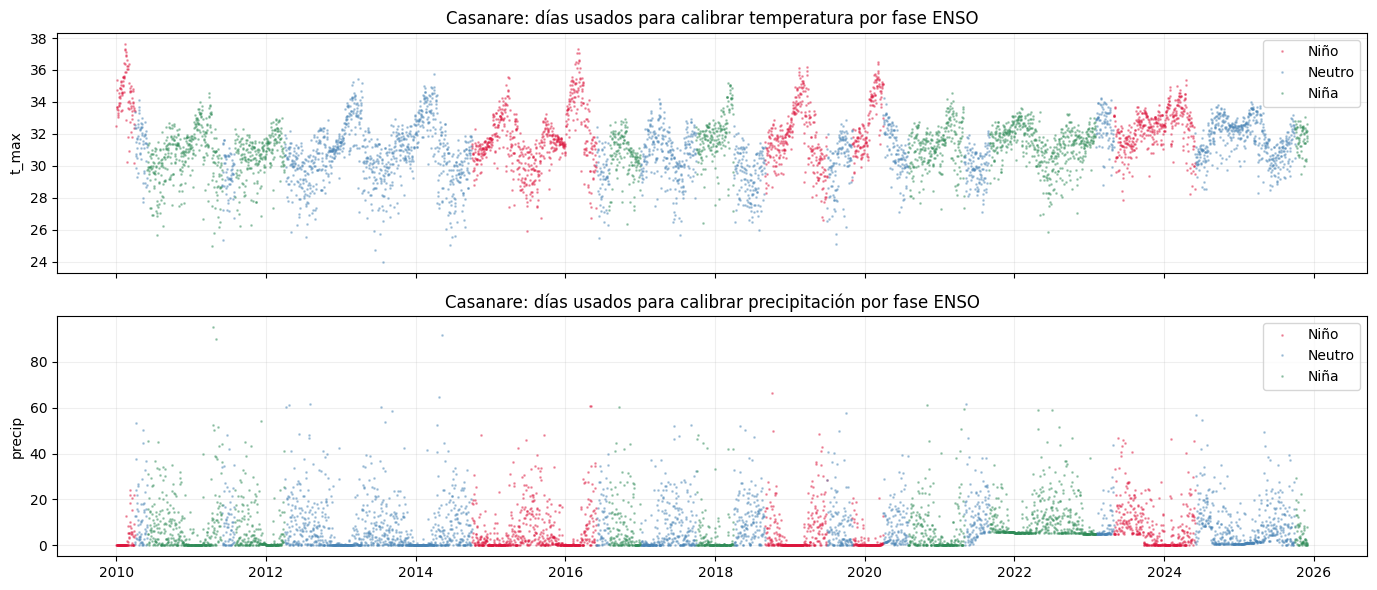

In [17]:

DEPARTAMENTOS = {"Tolima": df_Tolima, "Casanare": df_Casanare}
ESCENARIOS    = ["Niño", "Neutro", "Niña"]

def resumir_muestra_calibracion(df_dpto, nombre_dpto, var_temp=VAR_TEMP):
    """Muestra qué datos se usan para calibrar cada fase ENSO.

    Importante:
    - No es un solo intervalo continuo por fase.
    - Es el subconjunto histórico con df["fase"] == fase.
    - Por eso los días Niño/Neutro/Niña están repartidos en el tiempo.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    colors = {"Niño": "crimson", "Neutro": "steelblue", "Niña": "seagreen"}

    print(f"\n=== {nombre_dpto} ===")
    for fase in ESCENARIOS:
        sub = df_dpto.loc[df_dpto["fase"] == fase, [var_temp, "precip", "roni", "fase"]].copy()
        sub = sub.dropna(subset=[var_temp, "precip"])

        if sub.empty:
            print(f"{fase}: no hay observaciones")
            continue

        date_min = sub.index.min().date()
        date_max = sub.index.max().date()
        n_obs = len(sub)
        years = sub.index.year.value_counts().sort_index()

        print(f"\n{fase}")
        print(f"  Observaciones: {n_obs:,}")
        print(f"  Rango fecha:   {date_min} -> {date_max}")
        print(f"  Años cubiertos: {years.index.min()} -> {years.index.max()}")
        print(f"  Media {var_temp}:   {sub[var_temp].mean():.2f}")
        print(f"  Media precip:   {sub['precip'].mean():.2f}")

        display(years.rename("n_dias").to_frame())

        axes[0].plot(
            sub.index, sub[var_temp],
            linestyle="none", marker=".", markersize=2,
            alpha=0.35, color=colors[fase], label=fase
        )
        axes[1].plot(
            sub.index, sub["precip"],
            linestyle="none", marker=".", markersize=2,
            alpha=0.35, color=colors[fase], label=fase
        )

    axes[0].set_title(f"{nombre_dpto}: días usados para calibrar temperatura por fase ENSO")
    axes[0].set_ylabel(var_temp)
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].set_title(f"{nombre_dpto}: días usados para calibrar precipitación por fase ENSO")
    axes[1].set_ylabel("precip")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

for dpto, df_dpto in DEPARTAMENTOS.items():
    resumir_muestra_calibracion(df_dpto, dpto, var_temp=VAR_TEMP)

## 2. Simulación de temperatura (modelo Alaton)

Algoritmo:

1. Componente determinístico: $T^{\text{est}}_t = A + \sum_{k=1}^{K}\!\left(a_k \sin(\tfrac{2\pi k\, d_t}{365}) + b_k \cos(\tfrac{2\pi k\, d_t}{365})\right)$, con $K \in \{1, 2\}$.
2. Componente estocástico (AR(1) sobre residuales): $X_t = \alpha + \phi X_{t-1} + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}$ o $t$-Student según AIC (decidido en notebook 03).
3. $T_t = T^{\text{est}}_t + X_t$.

La temperatura simulada se inicializa en la distribución estacionaria del OU: $X_0 \sim \mathcal{N}(0,\, \sigma^2/(1-\phi^2))$.

In [18]:
def simular_temperatura(params_alaton, params_innov, dates, n_paths, seed=None,
                        x0_init=None):
    """Simula n_paths trayectorias diarias de temperatura siguiendo Alaton.

    Parámetros
    ----------
    x0_init : float | None
        Residual inicial X_0 = T_obs(t0-1) - T_seasonal(t0-1).  Si se pasa,
        la simulación arranca en este valor (continuidad con la historia) y
        el primer paso AR(1) usa este X_0 como lag.  Si es None, se sortea de
        la distribución estacionaria del proceso (modo "ergódico", default).
    """
    rng = np.random.default_rng(seed)
    n_dias = len(dates)
    d = dates.dayofyear.values

    coefs = params_alaton["ols_coefs"]
    seasonal = (coefs["const"]
                + coefs["sin"] * np.sin(2 * np.pi * d / 365)
                + coefs["cos"] * np.cos(2 * np.pi * d / 365))
    if params_alaton["n_armonicos"] == 2:
        seasonal += (coefs["sin2"] * np.sin(4 * np.pi * d / 365)
                     + coefs["cos2"] * np.cos(4 * np.pi * d / 365))

    phi   = params_alaton["phi"]
    alpha = params_alaton["alpha"]
    sigma = params_alaton["sigma"]

    # El notebook 03 exporta 'mejor' como 't-Student' o 'Normal' (criterio AIC)
    if params_innov["mejor"] == "t-Student":
        df_t  = max(params_innov["t"]["df"], 2.5)
        scale = params_innov["t"]["scale"]
        noise = rng.standard_t(df_t, size=(n_paths, n_dias)) * scale
    else:
        mu, sd = params_innov["normal"]["mu"], params_innov["normal"]["sigma"]
        noise  = rng.normal(mu, sd, size=(n_paths, n_dias))

    X = np.empty((n_paths, n_dias))
    if x0_init is None:
        # Modo ergódico: arrancar de la distribución estacionaria del AR(1)
        std_estac = sigma / np.sqrt(max(1 - phi**2, 1e-6))
        X[:, 0] = rng.normal(0, std_estac, size=n_paths)
    else:
        # Modo continuidad: arrancar del último residual observado y
        # construir X[:,0] = α + φ·x0_init + ε_0 (un paso AR(1) desde la historia)
        X[:, 0] = alpha + phi * float(x0_init) + noise[:, 0]
    for t in range(1, n_dias):
        X[:, t] = alpha + phi * X[:, t-1] + noise[:, t]

    return seasonal[None, :] + X


## 3. Simulación de precipitación (Bernoulli-Gamma)

Algoritmo para cada día $t$ y cada path:

1. Calcular features: **estacionalidad cíclica** ($\sin(2\pi d/365)$, $\cos(2\pi d/365)$) y **lags de precipitación** del mismo path ($P_{t-1}$, $P_{t-2}$).
2. **Logit**: $p_t = \sigma(\eta^{(L)}_t)$ donde $\eta^{(L)}_t$ es la combinación lineal de features con coeficientes del Logit.
3. Sortear ocurrencia: $\text{rain}_t \sim \text{Bernoulli}(p_t)$.
4. Si llueve: **Gamma**: $\mu_t = \exp(\eta^{(G)}_t)$ con coeficientes del Gamma; sortear intensidad $I_t \sim \text{Gamma}(\text{shape}=1/\phi_G, \text{scale}=\mu_t \phi_G)$ donde $\phi_G$ es el dispersion parameter de la GLM.
5. $P_t = \text{rain}_t \cdot I_t$.

> **Nota:** la simulación de precipitación es **independiente** de las trayectorias de temperatura (no comparten features), consistente con la decisión tomada en el notebook 05.


In [19]:
def simular_precipitacion(params_bg, dates, n_paths, seed=None,
                          lag_init=(0.0, 0.0)):
    """Simula n_paths trayectorias diarias de precipitación con Bernoulli-Gamma.

    El modelo usa estacionalidad cíclica y lags de la propia precipitación como
    features; no depende de las trayectorias de temperatura.

    Parámetros
    ----------
    lag_init : tuple(float, float)
        (lag1_obs, lag2_obs) = últimas dos precipitaciones observadas justo antes
        del inicio de la simulación, ordenadas como (más reciente, segunda más
        reciente).  Inicializa los lags para que la simulación enganche con la
        historia.  Default (0, 0) = "los dos días previos no llovió".

    Notas
    -----
    - Mismas reglas que el pronóstico recursivo del notebook 05:
      rain_t ~ Bernoulli(p_t); si llueve, intensidad ~ Gamma(shape=1/φ, scale=μφ).
    - Los dos primeros pasos usan lag_init en lugar de p_paths[:, -1] /
      p_paths[:, -2] (que serían los últimos días de la propia simulación por
      el wrap-around negativo de numpy — bug de la versión previa).
    """
    rng = np.random.default_rng(seed)
    n_dias = len(dates)
    d = dates.dayofyear.values
    sin_y = np.sin(2 * np.pi * d / 365)
    cos_y = np.cos(2 * np.pi * d / 365)

    lc = params_bg["logit_coefs"]
    gc = params_bg["gamma_coefs"]
    gs = params_bg["gamma_scale"]

    p_paths = np.zeros((n_paths, n_dias))
    lag1_hist, lag2_hist = float(lag_init[0]), float(lag_init[1])

    def _eta(coefs, t, lag1, lag2):
        return (coefs["const"]
                + coefs["sin_year"]    * sin_y[t]
                + coefs["cos_year"]    * cos_y[t]
                + coefs["lag1_precip"] * lag1
                + coefs["lag2_precip"] * lag2)

    for t in range(n_dias):
        if   t == 0:
            lag1 = np.full(n_paths, lag1_hist)
            lag2 = np.full(n_paths, lag2_hist)
        elif t == 1:
            lag1 = p_paths[:, 0]
            lag2 = np.full(n_paths, lag1_hist)
        else:
            lag1 = p_paths[:, t-1]
            lag2 = p_paths[:, t-2]

        eta_l  = _eta(lc, t, lag1, lag2)
        p_rain = 1.0 / (1.0 + np.exp(-eta_l))
        rains  = rng.random(n_paths) < p_rain

        eta_g = _eta(gc, t, lag1, lag2)
        mu_g  = np.exp(np.clip(eta_g, -10, 10))
        shape = 1.0 / gs
        scale = mu_g * gs
        intensity = np.clip(rng.gamma(shape, scale, size=n_paths), 0, 200)

        p_paths[:, t] = np.where(rains, intensity, 0.0)

    return p_paths


## 4. Re-calibración condicional por escenario ENSO

Para cada fase ENSO (Niño / Neutro / Niña) se re-estiman los parámetros del **componente estacional + AR(1)** (temperatura) y los **coeficientes del Logit/Gamma** (precipitación), manteniendo fija la estructura de regresores. Re-estimar el componente estacional por fase permite capturar el shift medio típico de cada escenario (Niño ~+0.5–1°C sobre el clima neutro).

El **threshold de "día lluvioso"** se toma de `params_bg.json` (decidido en el notebook 05 por departamento, vía análisis de sensibilidad): 3 mm para Casanare y 5 mm para Tolima.

Para robustez frente a no-convergencia en sub-muestras pequeñas, el Logit usa Newton-Raphson como método primario y reintenta con BFGS si Newton falla.

In [20]:
def calibrar_alaton_condicional(df_dpto, n_armonicos, fase, var_temp=VAR_TEMP):
    """Re-calibra OLS estacional + AR(1) sobre la sub-muestra de una fase ENSO."""
    sub = df_dpto[df_dpto["fase"] == fase].copy()
    d = sub.index.dayofyear

    regresores = {
        "sin": np.sin(2 * np.pi * d / 365),
        "cos": np.cos(2 * np.pi * d / 365),
    }
    if n_armonicos == 2:
        regresores["sin2"] = np.sin(4 * np.pi * d / 365)
        regresores["cos2"] = np.cos(4 * np.pi * d / 365)

    X_ols = sm.add_constant(pd.DataFrame(regresores, index=sub.index))
    ols   = sm.OLS(sub[var_temp], X_ols).fit()
    X_t   = sub[var_temp] - ols.predict(X_ols)

    lag = X_t.shift(1)
    ou_data = pd.concat([X_t, lag], axis=1).dropna()
    ou_data.columns = ["X", "X_lag"]
    ou = sm.OLS(ou_data["X"], sm.add_constant(ou_data["X_lag"])).fit()

    return {
        "phi":   float(ou.params["X_lag"]),
        "alpha": float(ou.params["const"]),
        "sigma": float(np.sqrt(ou.mse_resid)),
        "ols_coefs":   {k: float(v) for k, v in ols.params.items()},
        "n_armonicos": n_armonicos,
        "n_obs":       len(ou_data),
    }


def _fit_logit_robusto(y, X, fase=None):
    """Ajusta Logit usando Newton; reintenta con BFGS y maxiter alto si no converge."""
    try:
        m = sm.Logit(y, X).fit(method="newton", maxiter=100, disp=0)
        if not m.mle_retvals.get("converged", False):
            raise RuntimeError("Newton no convergió")
        return m
    except Exception:
        # Fallback: BFGS con más iteraciones
        m = sm.Logit(y, X).fit(method="bfgs", maxiter=500, disp=0)
        if not m.mle_retvals.get("converged", False):
            tag = f" [{fase}]" if fase else ""
            print(f"  [AVISO] Logit no convergió{tag}; usando el ajuste igualmente.")
        return m


def calibrar_bg_condicional(df_dpto, fase, threshold):
    """Re-ajusta Logit y Gamma sobre el subset de una fase ENSO."""
    sub = df_dpto[df_dpto["fase"] == fase].copy()
    d = sub.index.dayofyear
    sub["sin_year"] = np.sin(2 * np.pi * d / 365)
    sub["cos_year"] = np.cos(2 * np.pi * d / 365)
    sub["lag1_precip"] = sub["precip"].shift(1)
    sub["lag2_precip"] = sub["precip"].shift(2)
    sub["rain_flag"]   = (sub["precip"] > threshold).astype(int)
    sub = sub.dropna()

    VARS = ["sin_year", "cos_year", "lag1_precip", "lag2_precip"]
    X = sm.add_constant(sub[VARS])

    logit = _fit_logit_robusto(sub["rain_flag"], X, fase=fase)
    sub_l = sub[sub["rain_flag"] == 1]
    X_g   = sm.add_constant(sub_l[VARS])
    gamma = sm.GLM(sub_l["precip"], X_g,
                   family=sm.families.Gamma(link=sm.families.links.Log())).fit()

    return {
        "logit_coefs": logit.params.to_dict(),
        "gamma_coefs": gamma.params.to_dict(),
        "gamma_scale": float(gamma.scale),
        "n_obs":       len(sub),
        "threshold":   threshold,
    }

## 5. Generación de trayectorias

Para cada departamento × escenario ENSO se simulan `N_PATHS` trayectorias de 365 días. El threshold de lluvia se lee de `params_bg.json` por departamento.

In [21]:
DEPARTAMENTOS = {"Tolima": df_Tolima, "Casanare": df_Casanare}
ESCENARIOS    = ["Niño", "Neutro", "Niña"]

# fechas_sim arranca el día SIGUIENTE a la última observación histórica común
# a todos los departamentos (para que el plot de continuidad muestre el empalme
# real sin solapamiento calendario con la historia).
_last_dates = {dpto: df_d.dropna(subset=[VAR_TEMP, "precip"]).index.max()
               for dpto, df_d in DEPARTAMENTOS.items()}
_start_sim  = min(_last_dates.values()) + pd.Timedelta(days=1)
fechas_sim  = pd.date_range(_start_sim, periods=N_DIAS_SIM, freq="D")
print("Última obs histórica por dpto:")
for k, v in _last_dates.items():
    print(f"  {k}: {v.date()}")
print(f"Simulación: {fechas_sim[0].date()}  →  {fechas_sim[-1].date()}")

params_condicionales = {}
for dpto, df_dpto in DEPARTAMENTOS.items():
    params_condicionales[dpto] = {}
    n_arm     = P_ALATON[dpto]["n_armonicos"]
    threshold = P_BG[dpto]["threshold_lluvia"]
    for fase in ESCENARIOS:
        params_condicionales[dpto][fase] = {
            "alaton": calibrar_alaton_condicional(df_dpto, n_arm, fase),
            "bg":     calibrar_bg_condicional(df_dpto, fase, threshold=threshold),
        }

print("\nParámetros condicionales (intercepto OLS, persistencia y volatilidad del AR(1)):\n")
for dpto in DEPARTAMENTOS:
    thr = P_BG[dpto]["threshold_lluvia"]
    print(f"{dpto}  (threshold lluvia = {thr} mm):")
    for fase in ESCENARIOS:
        p = params_condicionales[dpto][fase]["alaton"]
        const = p["ols_coefs"]["const"]
        print(f"  {fase:7s}  T_media={const:.2f}°C  φ={p['phi']:.4f}  σ={p['sigma']:.4f}  (n={p['n_obs']:,})")


Última obs histórica por dpto:
  Tolima: 2025-12-01
  Casanare: 2025-12-01
Simulación: 2025-12-02  →  2026-12-01

Parámetros condicionales (intercepto OLS, persistencia y volatilidad del AR(1)):

Tolima  (threshold lluvia = 5 mm):
  Niño     T_media=31.21°C  φ=0.6038  σ=1.3478  (n=1,550)
  Neutro   T_media=30.31°C  φ=0.5290  σ=1.2935  (n=2,465)
  Niña     T_media=29.48°C  φ=0.4551  σ=1.2250  (n=1,796)
Casanare  (threshold lluvia = 3 mm):
  Niño     T_media=31.79°C  φ=0.5283  σ=1.0922  (n=1,550)
  Neutro   T_media=31.15°C  φ=0.4388  σ=1.2238  (n=2,465)
  Niña     T_media=30.88°C  φ=0.3949  σ=1.1445  (n=1,796)


In [22]:
def _initial_conditions(df_dpto, params_alaton_dpto, var_temp=VAR_TEMP):
    """Calcula condiciones iniciales para enganchar la simulación con la historia.

    Devuelve:
      x0_resid : float — último residual observado T - T_seasonal (para Alaton).
      lag_init : (float, float) — últimas dos precipitaciones observadas
                 (más reciente, segunda más reciente), para BG.
    """
    sub = df_dpto.dropna(subset=[var_temp, "precip"]).sort_index()
    last  = sub.iloc[-1]
    prev  = sub.iloc[-2]

    # Residual de temperatura: T_obs(t_last) - seasonal_alaton(t_last)
    # Usa los coeficientes UNCONDICIONALES (P_ALATON) para definir el componente
    # estacional de la historia — son los que ajustaron T_obs en notebook 02.
    coefs = params_alaton_dpto["ols_coefs"]
    d_last = sub.index[-1].dayofyear
    seas = (coefs["const"]
            + coefs["sin"] * np.sin(2 * np.pi * d_last / 365)
            + coefs["cos"] * np.cos(2 * np.pi * d_last / 365))
    if params_alaton_dpto["n_armonicos"] == 2:
        seas += (coefs["sin2"] * np.sin(4 * np.pi * d_last / 365)
                 + coefs["cos2"] * np.cos(4 * np.pi * d_last / 365))
    x0_resid = float(last[var_temp] - seas)

    lag_init = (float(last["precip"]), float(prev["precip"]))
    return x0_resid, lag_init


print(f"\nSimulando {N_PATHS:,} paths × {N_DIAS_SIM} días por escenario...\n")
sims = {}
init_conds = {}
for dpto in DEPARTAMENTOS:
    sims[dpto] = {}
    # Condiciones iniciales: última observación histórica (común a las 3 fases —
    # el "estado de hoy" es el mismo; lo que cambia por fase es la dinámica futura).
    x0_resid, lag_init = _initial_conditions(DEPARTAMENTOS[dpto], P_ALATON[dpto])
    init_conds[dpto] = {"x0_resid": x0_resid, "lag_init": lag_init,
                        "last_date": DEPARTAMENTOS[dpto].index[-1]}
    print(f"  {dpto}: último día = {init_conds[dpto]['last_date'].date()}  "
          f"X₀_resid={x0_resid:+.2f}°C  lag1={lag_init[0]:.1f}mm  lag2={lag_init[1]:.1f}mm")

    for i_f, fase in enumerate(ESCENARIOS):
        p_alaton = params_condicionales[dpto][fase]["alaton"]
        p_bg     = params_condicionales[dpto][fase]["bg"]
        p_innov  = P_INNOV[dpto]

        seed_t = SEED + i_f * 1000 + (0 if dpto == "Tolima" else 100)
        seed_p = seed_t + 1

        t_paths = simular_temperatura(p_alaton, p_innov, fechas_sim, N_PATHS,
                                      seed=seed_t, x0_init=x0_resid)
        p_paths = simular_precipitacion(p_bg, fechas_sim, N_PATHS,
                                        seed=seed_p, lag_init=lag_init)

        sims[dpto][fase] = {"t_paths": t_paths, "p_paths": p_paths}
        print(f"  {dpto:10s} {fase:7s} → "
              f"T_media={t_paths.mean():.2f}°C   "
              f"Precip_anual_media={p_paths.sum(axis=1).mean():.0f} mm")



Simulando 10,000 paths × 365 días por escenario...

  Tolima: último día = 2025-12-01  X₀_resid=-0.15°C  lag1=11.4mm  lag2=6.1mm
  Tolima     Niño    → T_media=31.21°C   Precip_anual_media=1262 mm
  Tolima     Neutro  → T_media=30.30°C   Precip_anual_media=1564 mm
  Tolima     Niña    → T_media=29.48°C   Precip_anual_media=1967 mm
  Casanare: último día = 2025-12-01  X₀_resid=+1.33°C  lag1=8.1mm  lag2=0.7mm
  Casanare   Niño    → T_media=31.80°C   Precip_anual_media=2579 mm
  Casanare   Neutro  → T_media=31.15°C   Precip_anual_media=2433 mm
  Casanare   Niña    → T_media=30.89°C   Precip_anual_media=3069 mm


## 6. Validación: simulado vs histórico

Estadísticos comparativos entre las trayectorias simuladas y los datos históricos de cada fase, más envelopes de cuantiles 5–95% sobre paths.


TOLIMA  (threshold lluvia = 5 mm)

--- Tolima | Niño ---
  T_media hist:  μ=30.99°C  σ=1.92°C
  T_media sim:   μ=31.21°C  σ_intra-path=1.96°C
  Precip diaria hist:  μ=4.79 mm   pct_lluvia(>5mm)=30.8%
  Precip diaria sim:   μ=3.46 mm   pct_lluvia(>5mm)=23.9%
  Precip anual hist: μ=826 mm  (n_años=9)
  Precip anual sim:  μ=1262 mm

--- Tolima | Neutro ---
  T_media hist:  μ=30.49°C  σ=1.83°C
  T_media sim:   μ=30.30°C  σ_intra-path=1.83°C
  Precip diaria hist:  μ=5.21 mm   pct_lluvia(>5mm)=32.7%
  Precip diaria sim:   μ=4.29 mm   pct_lluvia(>5mm)=29.2%
  Precip anual hist: μ=918 mm  (n_años=14)
  Precip anual sim:  μ=1564 mm

--- Tolima | Niña ---
  T_media hist:  μ=29.47°C  σ=1.57°C
  T_media sim:   μ=29.48°C  σ_intra-path=1.65°C
  Precip diaria hist:  μ=6.73 mm   pct_lluvia(>5mm)=44.4%
  Precip diaria sim:   μ=5.39 mm   pct_lluvia(>5mm)=36.2%
  Precip anual hist: μ=1100 mm  (n_años=11)
  Precip anual sim:  μ=1967 mm


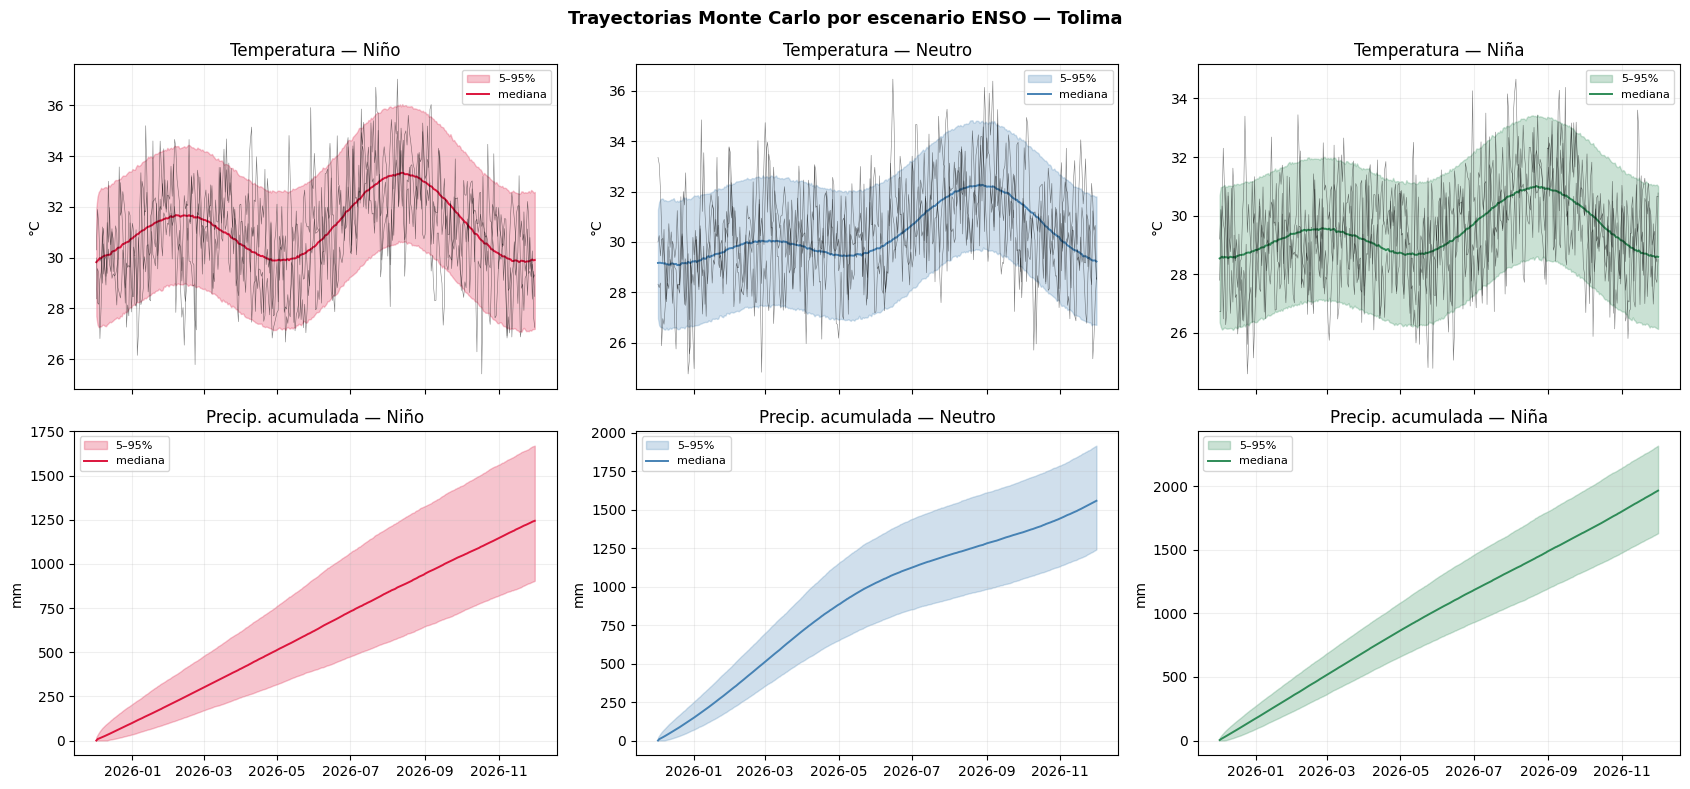


CASANARE  (threshold lluvia = 3 mm)

--- Casanare | Niño ---
  T_media hist:  μ=32.09°C  σ=1.82°C
  T_media sim:   μ=31.80°C  σ_intra-path=1.89°C
  Precip diaria hist:  μ=5.94 mm   pct_lluvia(>3mm)=42.7%
  Precip diaria sim:   μ=7.06 mm   pct_lluvia(>3mm)=46.3%
  Precip anual hist: μ=1024 mm  (n_años=9)
  Precip anual sim:  μ=2579 mm

--- Casanare | Neutro ---
  T_media hist:  μ=30.81°C  σ=1.72°C
  T_media sim:   μ=31.15°C  σ_intra-path=1.67°C
  Precip diaria hist:  μ=8.61 mm   pct_lluvia(>3mm)=58.4%
  Precip diaria sim:   μ=6.67 mm   pct_lluvia(>3mm)=44.5%
  Precip anual hist: μ=1516 mm  (n_años=14)
  Precip anual sim:  μ=2433 mm

--- Casanare | Niña ---
  T_media hist:  μ=31.11°C  σ=1.42°C
  T_media sim:   μ=30.89°C  σ_intra-path=1.57°C
  Precip diaria hist:  μ=7.56 mm   pct_lluvia(>3mm)=57.4%
  Precip diaria sim:   μ=8.41 mm   pct_lluvia(>3mm)=52.9%
  Precip anual hist: μ=1236 mm  (n_años=11)
  Precip anual sim:  μ=3069 mm


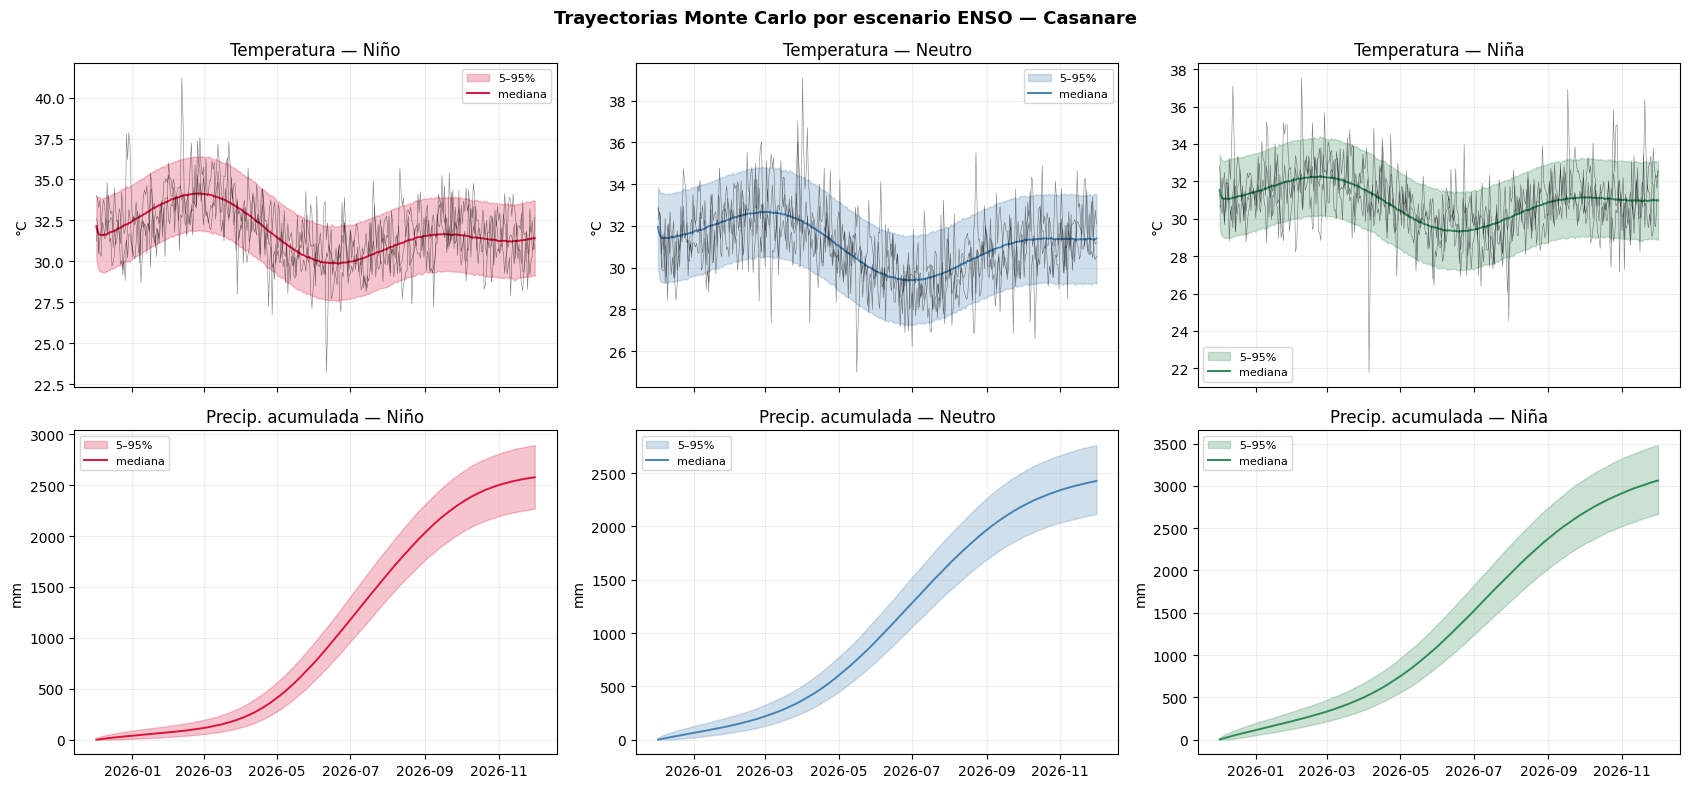

In [23]:
def comparar_simulado_vs_historico(df_dpto, sims_dpto, nombre_dpto, fase, threshold, var_temp=VAR_TEMP):
    """Imprime estadísticos comparativos para una fase ENSO."""
    hist  = df_dpto[df_dpto["fase"] == fase]
    t_sim = sims_dpto[fase]["t_paths"]
    p_sim = sims_dpto[fase]["p_paths"]

    print(f"\n--- {nombre_dpto} | {fase} ---")
    print(f"  T_media hist:  μ={hist[var_temp].mean():.2f}°C  σ={hist[var_temp].std():.2f}°C")
    print(f"  T_media sim:   μ={t_sim.mean():.2f}°C  σ_intra-path={t_sim.std(axis=1).mean():.2f}°C")
    print(f"  Precip diaria hist:  μ={hist['precip'].mean():.2f} mm   pct_lluvia(>{threshold}mm)={(hist['precip']>threshold).mean()*100:.1f}%")
    print(f"  Precip diaria sim:   μ={p_sim.mean():.2f} mm   pct_lluvia(>{threshold}mm)={(p_sim>threshold).mean()*100:.1f}%")
    p_anual_hist = hist.groupby(hist.index.year)["precip"].sum()
    print(f"  Precip anual hist: μ={p_anual_hist.mean():.0f} mm  (n_años={len(p_anual_hist)})")
    print(f"  Precip anual sim:  μ={p_sim.sum(axis=1).mean():.0f} mm")


def graficar_envelope(sims_dpto, fechas, nombre_dpto):
    fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex=True)
    colores = {"Niño": "crimson", "Neutro": "steelblue", "Niña": "seagreen"}

    for j, fase in enumerate(ESCENARIOS):
        t_paths = sims_dpto[fase]["t_paths"]
        p_paths = sims_dpto[fase]["p_paths"]
        c = colores[fase]

        ax = axes[0, j]
        q_lo, q_med, q_hi = np.percentile(t_paths, [5, 50, 95], axis=0)
        ax.fill_between(fechas, q_lo, q_hi, color=c, alpha=0.25, label="5–95%")
        ax.plot(fechas, q_med, color=c, lw=1.4, label="mediana")
        for i in range(min(3, len(t_paths))):
            ax.plot(fechas, t_paths[i], color="black", lw=0.4, alpha=0.5)
        ax.set_title(f"Temperatura — {fase}")
        ax.set_ylabel("°C"); ax.grid(alpha=0.2); ax.legend(fontsize=8)

        ax = axes[1, j]
        cum = np.cumsum(p_paths, axis=1)
        q_lo, q_med, q_hi = np.percentile(cum, [5, 50, 95], axis=0)
        ax.fill_between(fechas, q_lo, q_hi, color=c, alpha=0.25, label="5–95%")
        ax.plot(fechas, q_med, color=c, lw=1.4, label="mediana")
        ax.set_title(f"Precip. acumulada — {fase}")
        ax.set_ylabel("mm"); ax.grid(alpha=0.2); ax.legend(fontsize=8)

    fig.suptitle(f"Trayectorias Monte Carlo por escenario ENSO — {nombre_dpto}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


for dpto, df_dpto in DEPARTAMENTOS.items():
    threshold = P_BG[dpto]["threshold_lluvia"]
    print(f"\n{'='*70}\n{dpto.upper()}  (threshold lluvia = {threshold} mm)\n{'='*70}")
    for fase in ESCENARIOS:
        comparar_simulado_vs_historico(df_dpto, sims[dpto], dpto, fase, threshold)
    graficar_envelope(sims[dpto], fechas_sim, dpto)

## 6.1 Continuidad histórico → simulado

Para verificar visualmente que las trayectorias enganchan con la última observación, se muestra el último año del histórico seguido del año simulado (`fechas_sim` arranca el día siguiente a la última observación histórica). Si la inicialización es correcta y la calibración estacional es adecuada, **no debe haber un salto discontinuo en el empalme ni una tendencia monotónica en la simulación** — lo que se vea variar a lo largo del año simulado debe corresponder al ciclo estacional, no a un drift artificial.

> **Nota técnica:** para precipitación se muestran percentiles **sobre la media móvil de 30 días de cada trayectoria**, no sobre los valores diarios. La razón: la precipitación es intermitente (>50% de días secos), por lo que un percentil diario de los paths daría mediana ≈ 0 incluso cuando el promedio mensual es de varios mm/día. Suavizando primero por path y luego sacando percentiles entre paths se obtiene el envelope correcto del nivel promedio mensual.

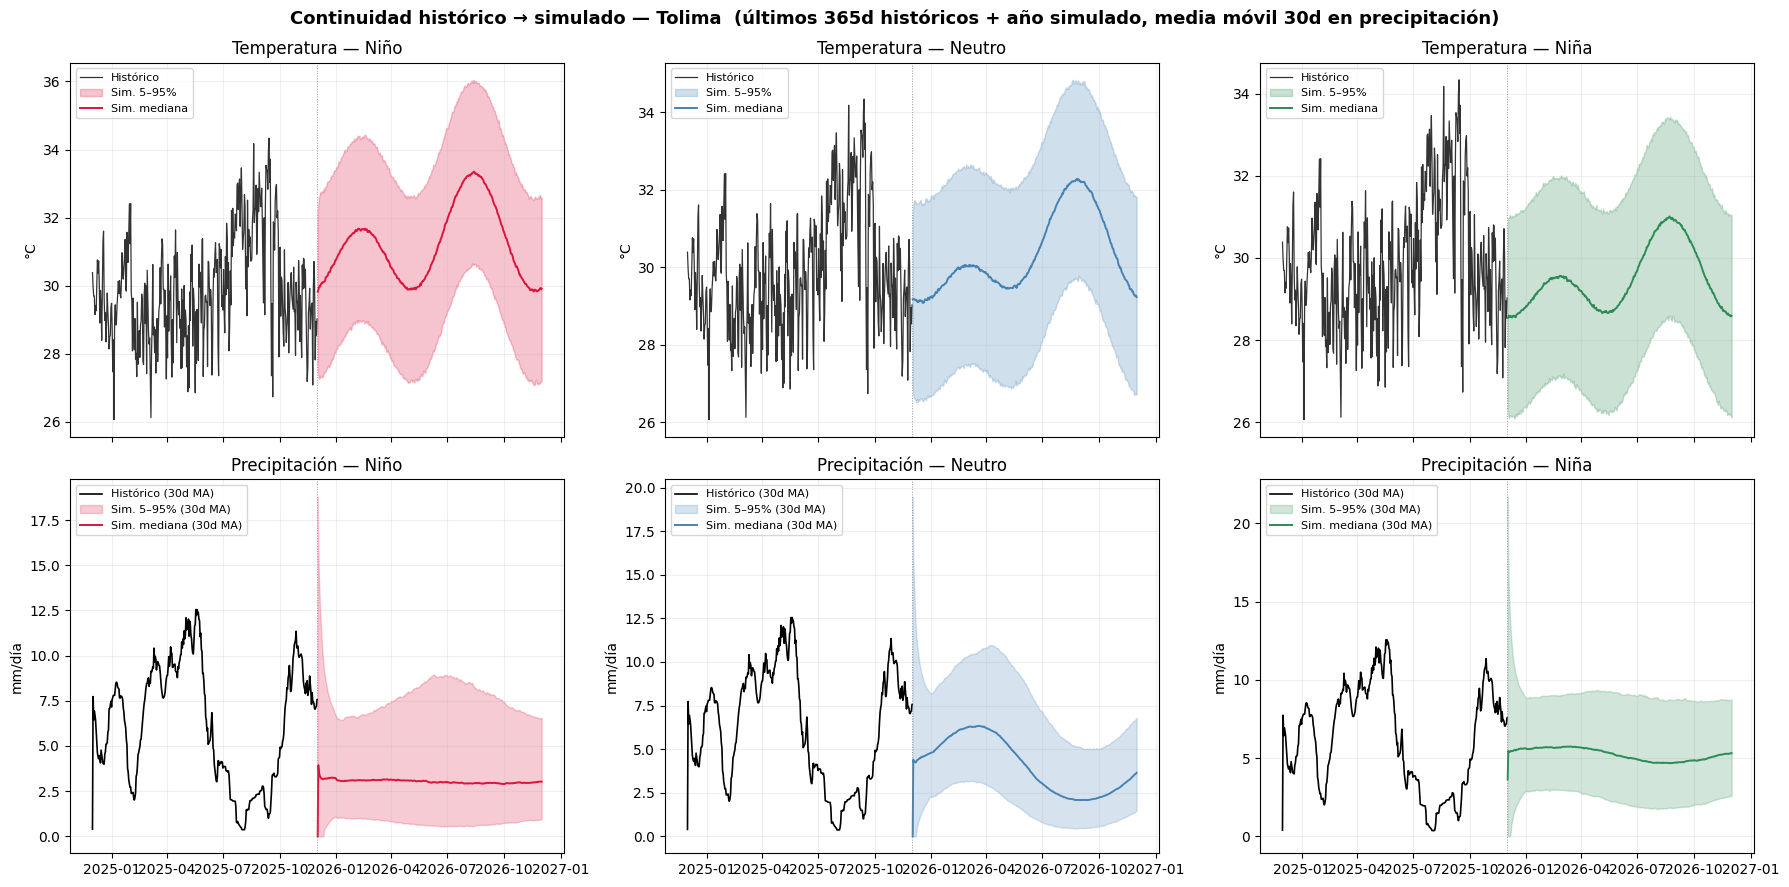

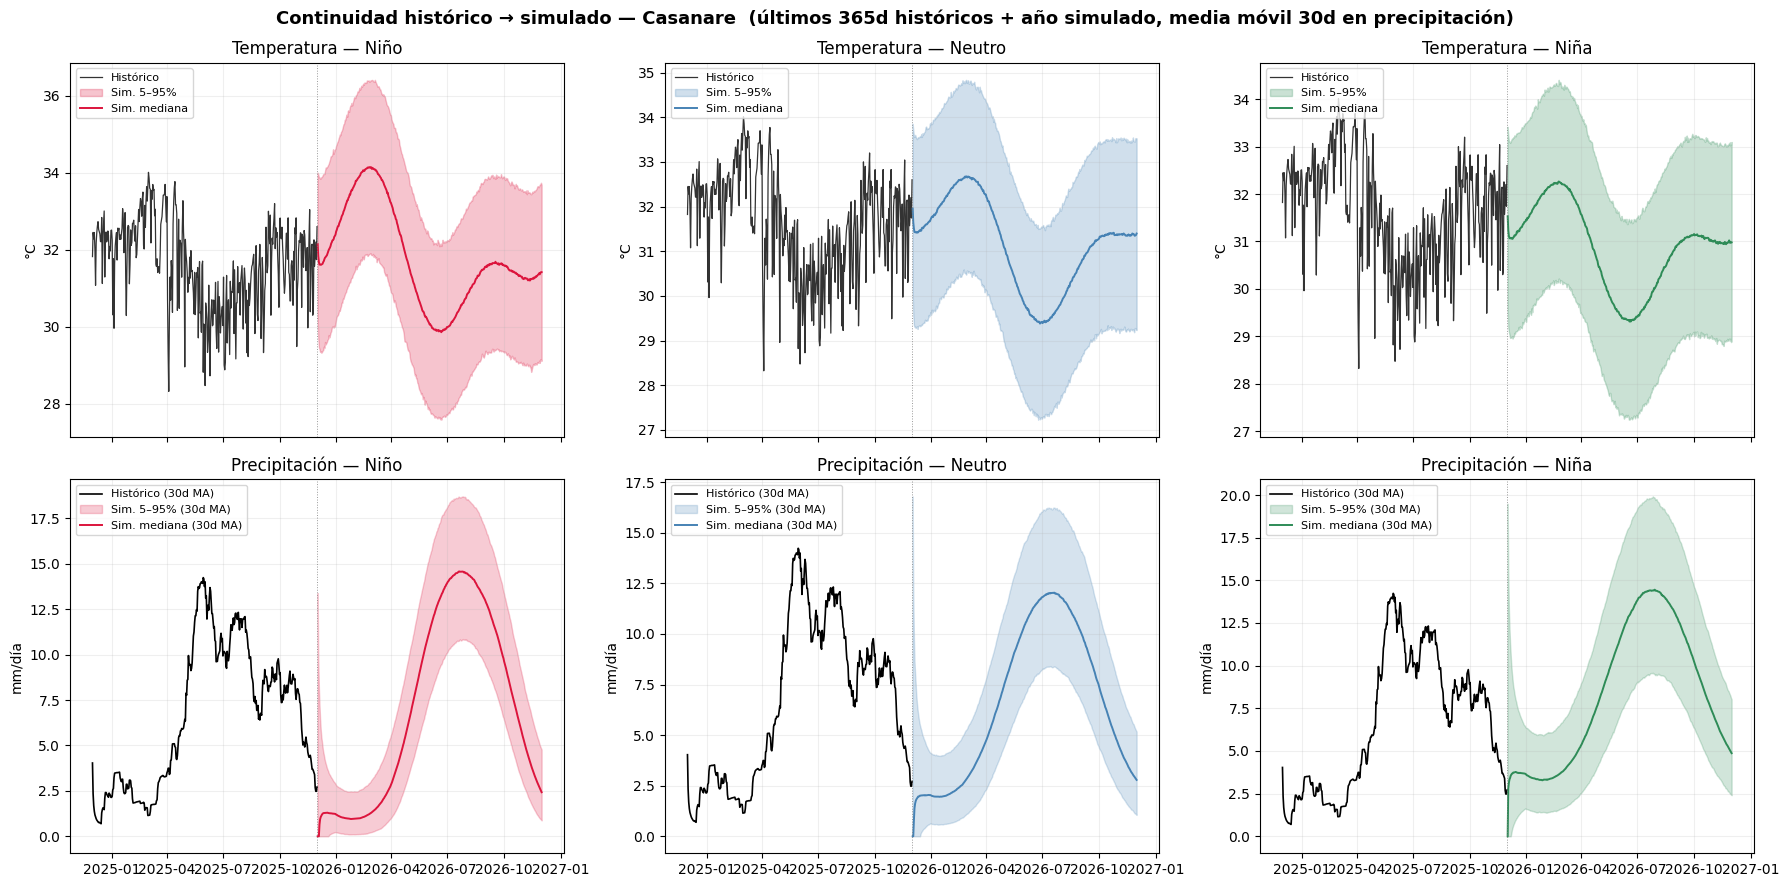

In [24]:
def graficar_continuidad(df_dpto, sims_dpto, fechas_sim, init_conds_dpto,
                          nombre_dpto, ventana_hist=365, ventana_mavg=30, var_temp=VAR_TEMP):
    """Plot histórico final + envelope simulado para cada fase ENSO.

    Layout 2×3 (temp arriba, precip abajo; una columna por fase):

      Temperatura — línea negra del histórico (últimos `ventana_hist` días)
                    seguida del envelope 5–95% y mediana simulada. Línea
                    vertical punteada marca el día del empalme.

      Precipitación — media móvil 30d del histórico (línea negra) seguida
                     del envelope 5–95% y mediana simulada SOBRE LA MEDIA
                     MÓVIL DE CADA TRAYECTORIA. Esto es lo correcto para
                     un proceso intermitente como BG: suavizar primero cada
                     path (los días secos se mezclan con los lluviosos en
                     la ventana) y luego sacar percentiles entre paths
                     captura la variabilidad path-a-path del nivel medio
                     mensual. El error de hacerlo al revés (percentil diario
                     y luego suavizar) da mediana ≈ 0 porque > 50% de los
                     días son secos.
    """
    last_date = init_conds_dpto["last_date"]
    hist_window = df_dpto.loc[last_date - pd.Timedelta(days=ventana_hist):last_date]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
    colores = {"Niño": "crimson", "Neutro": "steelblue", "Niña": "seagreen"}

    hist_precip_mavg = hist_window["precip"].rolling(ventana_mavg, min_periods=1).mean()
    #hist_precip_mavg = hist_window["precip"].rolling(ventana_mavg, center=True).mean()

    for j, fase in enumerate(ESCENARIOS):
        t_paths = sims_dpto[fase]["t_paths"]
        p_paths = sims_dpto[fase]["p_paths"]
        c = colores[fase]

        # ─── Temperatura ────────────────────────────────────────────────
        ax = axes[0, j]
        ax.plot(hist_window.index, hist_window[var_temp], color="black",
                lw=0.9, alpha=0.8, label="Histórico")
        q_lo, q_med, q_hi = np.percentile(t_paths, [5, 50, 95], axis=0)
        ax.fill_between(fechas_sim, q_lo, q_hi, color=c, alpha=0.25,
                        label="Sim. 5–95%")
        ax.plot(fechas_sim, q_med, color=c, lw=1.4, label="Sim. mediana")
        ax.axvline(last_date, color="grey", lw=0.7, ls=":", alpha=0.8)
        ax.set_title(f"Temperatura — {fase}")
        ax.set_ylabel("°C"); ax.grid(alpha=0.2); ax.legend(fontsize=8, loc="upper left")

        # ─── Precipitación: SUAVIZAR cada path primero, LUEGO percentiles ─
        ax = axes[1, j]
        ax.plot(hist_window.index, hist_precip_mavg, color="black",
                lw=1.2, label=f"Histórico ({ventana_mavg}d MA)")

        # rolling mean por path (axis=1 = a lo largo del tiempo)
        #p_paths_smooth = pd.DataFrame(p_paths.T).rolling(ventana_mavg, center=True).mean().T.values
        
        p_paths_smooth = (
            pd.DataFrame(p_paths.T)
            .rolling(ventana_mavg, min_periods=1)
            .mean()
            .T.values
        )
        p_lo  = np.nanpercentile(p_paths_smooth,  5, axis=0)
        p_med = np.nanpercentile(p_paths_smooth, 50, axis=0)
        p_hi  = np.nanpercentile(p_paths_smooth, 95, axis=0)
        ax.fill_between(fechas_sim, p_lo, p_hi, color=c, alpha=0.22,
                        label=f"Sim. 5–95% ({ventana_mavg}d MA)")
        ax.plot(fechas_sim, p_med, color=c, lw=1.4,
                label=f"Sim. mediana ({ventana_mavg}d MA)")
        ax.axvline(last_date, color="grey", lw=0.7, ls=":", alpha=0.8)
        ax.set_title(f"Precipitación — {fase}")
        ax.set_ylabel("mm/día"); ax.grid(alpha=0.2); ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(f"Continuidad histórico → simulado — {nombre_dpto}  "
                 f"(últimos {ventana_hist}d históricos + año simulado, "
                 f"media móvil {ventana_mavg}d en precipitación)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


for dpto, df_dpto in DEPARTAMENTOS.items():
    graficar_continuidad(df_dpto, sims[dpto], fechas_sim, init_conds[dpto], dpto, var_temp=VAR_TEMP)


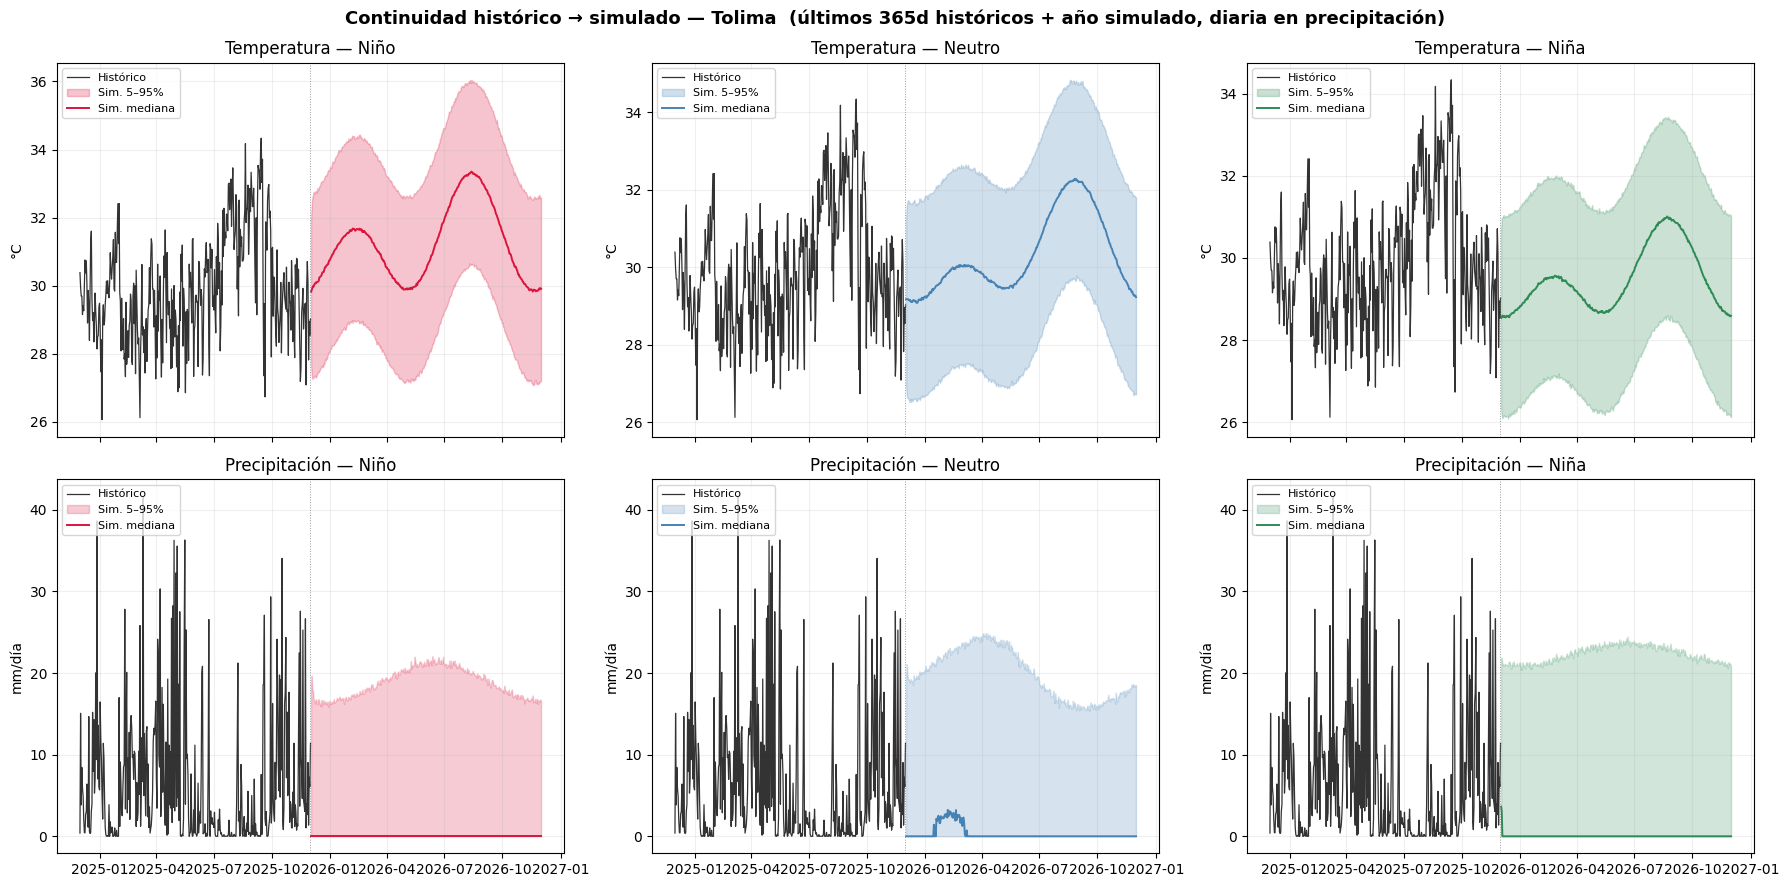

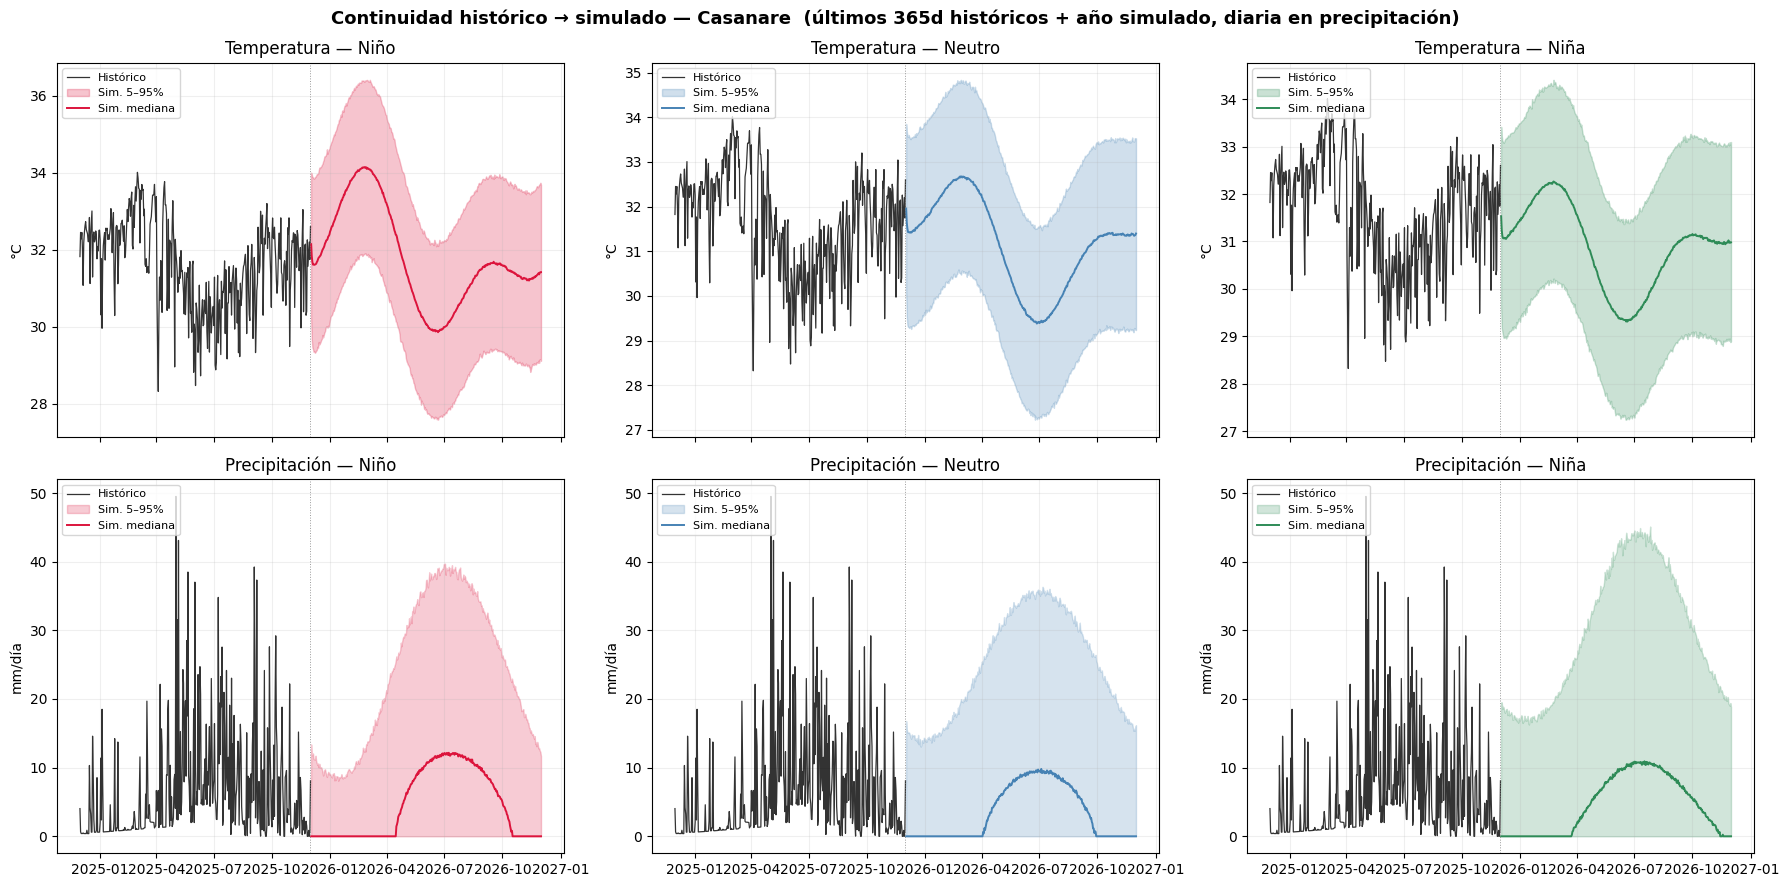

In [25]:
def graficar_continuidad(df_dpto, sims_dpto, fechas_sim, init_conds_dpto,
                         nombre_dpto, ventana_hist=365, var_temp=VAR_TEMP):
    """Plot histórico final + envelope simulado para cada fase ENSO.

    Layout 2×3 (temp arriba, precip abajo; una columna por fase):

      Temperatura — línea negra del histórico (últimos `ventana_hist` días)
                    seguida del envelope 5–95% y mediana simulada. Línea
                    vertical punteada marca el día del empalme.

      Precipitación — serie diaria histórica seguida del envelope 5–95% y
                      mediana simulada diaria. No se aplica media móvil.
    """
    last_date = init_conds_dpto["last_date"]
    hist_window = df_dpto.loc[last_date - pd.Timedelta(days=ventana_hist):last_date]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
    colores = {"Niño": "crimson", "Neutro": "steelblue", "Niña": "seagreen"}

    for j, fase in enumerate(ESCENARIOS):
        t_paths = sims_dpto[fase]["t_paths"]
        p_paths = sims_dpto[fase]["p_paths"]
        c = colores[fase]

        ax = axes[0, j]
        ax.plot(hist_window.index, hist_window[var_temp], color="black",
                lw=0.9, alpha=0.8, label="Histórico")
        q_lo, q_med, q_hi = np.percentile(t_paths, [5, 50, 95], axis=0)
        ax.fill_between(fechas_sim, q_lo, q_hi, color=c, alpha=0.25,
                        label="Sim. 5–95%")
        ax.plot(fechas_sim, q_med, color=c, lw=1.4, label="Sim. mediana")
        ax.axvline(last_date, color="grey", lw=0.7, ls=":", alpha=0.8)
        ax.set_title(f"Temperatura — {fase}")
        ax.set_ylabel("°C")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc="upper left")

        ax = axes[1, j]
        ax.plot(hist_window.index, hist_window["precip"], color="black",
                lw=0.9, alpha=0.8, label="Histórico")
        p_lo, p_med, p_hi = np.percentile(p_paths, [5, 50, 95], axis=0)
        ax.fill_between(fechas_sim, p_lo, p_hi, color=c, alpha=0.22,
                        label="Sim. 5–95%")
        ax.plot(fechas_sim, p_med, color=c, lw=1.4, label="Sim. mediana")
        ax.axvline(last_date, color="grey", lw=0.7, ls=":", alpha=0.8)
        ax.set_title(f"Precipitación — {fase}")
        ax.set_ylabel("mm/día")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(f"Continuidad histórico → simulado — {nombre_dpto}  "
                 f"(últimos {ventana_hist}d históricos + año simulado, diaria en precipitación)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
for dpto, df_dpto in DEPARTAMENTOS.items():
    graficar_continuidad(df_dpto, sims[dpto], fechas_sim, init_conds[dpto], dpto, var_temp=VAR_TEMP)

## 7. Exportación de trayectorias

Las trayectorias se exportan en formato largo a `data/processed/mc_paths.parquet` para uso en los notebooks 07 (índices HDD/CRI) y 08 (valoración).

In [26]:
filas = []
for dpto in DEPARTAMENTOS:
    for fase in ESCENARIOS:
        t_paths = sims[dpto][fase]["t_paths"]
        p_paths = sims[dpto][fase]["p_paths"]
        for path_id in range(N_PATHS):
            filas.append(pd.DataFrame({
                "dpto":    dpto,
                "fase":    fase,
                "path_id": path_id,
                "date":    fechas_sim,
                "t_max":  t_paths[path_id],
                "precip":  p_paths[path_id],
            }))

mc_long = pd.concat(filas, ignore_index=True)
print(f"DataFrame final: {mc_long.shape}")
print(mc_long.head())

for col in ["dpto", "fase"]:
    mc_long[col] = mc_long[col].astype("category")

out_path = OUT_DIR / "mc_paths.parquet"
mc_long.to_parquet(out_path, index=False)
print(f"\nTrayectorias exportadas a: {out_path}  ({out_path.stat().st_size/1e6:.1f} MB)")

DataFrame final: (21900000, 6)
     dpto  fase  path_id       date      t_max  precip
0  Tolima  Niño        0 2025-12-02  30.306908     0.0
1  Tolima  Niño        0 2025-12-03  31.900128     0.0
2  Tolima  Niño        0 2025-12-04  31.314500     0.0
3  Tolima  Niño        0 2025-12-05  29.857341     0.0
4  Tolima  Niño        0 2025-12-06  29.996099     0.0

Trayectorias exportadas a: ..\data\processed\mc_paths.parquet  (288.3 MB)
